In [52]:
import os, pickle
import numpy as np
import matplotlib.pyplot as plt

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

with open('extracted-data/data_new.pkl', 'rb') as f:
    data = pickle.load(f)

Loaded 418,139 PFOs  |  117,735 pions


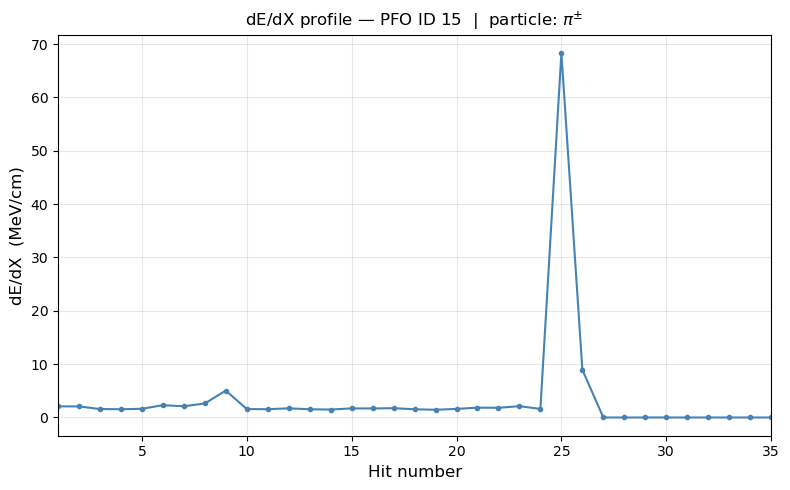

In [71]:
PION_CLASS = '$\\pi^{\\pm}$'
pions = [pfo for pfo in data if PION_CLASS in pfo['particle']]
print(f'Loaded {len(data):,} PFOs  |  {len(pions):,} pions')

PFO_ID = 15
LENGTH = 35  # set to an int to truncate, or None for full 222

pfo      = pions[PFO_ID - 1]
particle = pfo['particle']
dedx     = np.array(pfo['dEdX_sequence'])
if LENGTH is not None:
    dedx = dedx[:LENGTH]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(dedx) + 1), dedx, color='steelblue', lw=1.5, marker='o', markersize=3)
ax.set_xlabel('Hit number', fontsize=12)
ax.set_ylabel('dE/dX  (MeV/cm)', fontsize=12)
ax.set_title(f'dE/dX profile — PFO ID {PFO_ID}  |  particle: {particle}', fontsize=12)
ax.set_xlim(1, len(dedx))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()